# Distribution Shift Analysis

This notebook characterises the distribution shift between GUIDE-seq and CHANGE-seq using the preprocessed datasets and DNABERT deep ensemble.

The analysis separates three related effects: guide familiarity, assay-dependent differences in observed labels, and changes in model behaviour under cross-assay evaluation. Exact genomic sites measured in both assays are compared to determine whether observed labels differ even when guide and candidate-site composition are controlled.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from scipy.special import expit
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss)

In [2]:
os.makedirs('results', exist_ok=True)

In [3]:
DATA_DIR = 'data/processed/'
GRNA_COL = 'target'
SITE_KEY = [GRNA_COL, 'chrom', 'chromStart', 'strand']

guide_train = pd.read_csv(DATA_DIR + 'guide_train.csv', low_memory=False)
guide_test = pd.read_csv(DATA_DIR + 'guide_test.csv', low_memory=False)
change_train = pd.read_csv(DATA_DIR + 'change_train.csv', low_memory=False)
change_test = pd.read_csv(DATA_DIR + 'change_test.csv', low_memory=False)

guide_full = pd.concat([guide_train, guide_test], ignore_index=True)
change_full = pd.concat([change_train, change_test], ignore_index=True)

# Final preprocessing should contain one row per genomic site.
assert guide_full.duplicated(subset=SITE_KEY).sum() == 0
assert change_full.duplicated(subset=SITE_KEY).sum() == 0

# Within each assay, train and test guides must remain disjoint.
assert set(guide_train[GRNA_COL]).isdisjoint(set(guide_test[GRNA_COL]))
assert set(change_train[GRNA_COL]).isdisjoint(set(change_test[GRNA_COL]))

print(
    f'GUIDE-seq full: {len(guide_full):,} rows, '
    f'{guide_full[GRNA_COL].nunique()} guides'
)
print(
    f'CHANGE-seq full: {len(change_full):,} rows, '
    f'{change_full[GRNA_COL].nunique()} guides'
)

print(f'\nGUIDE train: {len(guide_train):,}')
print(f'GUIDE test: {len(guide_test):,}')
print(f'CHANGE train: {len(change_train):,}')
print(f'CHANGE test: {len(change_test):,}')

GUIDE-seq full: 1,477,762 rows, 58 guides
CHANGE-seq full: 2,873,627 rows, 110 guides

GUIDE train: 1,229,148
GUIDE test: 248,614
CHANGE train: 2,352,636
CHANGE test: 520,991


In [4]:
y_guide_test = guide_test['label'].to_numpy()
y_change_test = change_test['label'].to_numpy()

guide_logits = np.load(DATA_DIR + 'guide_member_logits.npy')
change_logits = np.load(DATA_DIR + 'change_member_logits.npy')

metadata = np.load(DATA_DIR + 'ensemble_training_metadata.npz')

negative_sampling_rate = float(metadata['negative_sampling_rate'])
OFFSET = float(metadata['sampling_logit_offset'])

# Checking saved predictions still align with the final test sets.
assert guide_logits.shape == (5, len(y_guide_test))
assert change_logits.shape == (5, len(y_change_test))

assert np.isfinite(guide_logits).all()
assert np.isfinite(change_logits).all()

# Applies the training-prior correction to each member before averaging.
guide_member_probs = expit(guide_logits + OFFSET)
change_member_probs = expit(change_logits + OFFSET)

guide_mean_probs = guide_member_probs.mean(axis=0)
change_mean_probs = change_member_probs.mean(axis=0)

# Ensemble disagreement as the epistemic uncertainty proxy.
guide_uncertainty = guide_member_probs.var(axis=0)
change_uncertainty = change_member_probs.var(axis=0)

print(f'GUIDE logits: {guide_logits.shape}')
print(f'CHANGE logits: {change_logits.shape}')

print(f'\nNegative sampling rate: {negative_sampling_rate:.8f}')
print(f'Logit correction offset: {OFFSET:.6f}')

GUIDE logits: (5, 248614)
CHANGE logits: (5, 520991)

Negative sampling rate: 0.01116652
Logit correction offset: -4.494835


In [5]:
def ece(y, p, n_bins=10, strategy='quantile'):
    if strategy == 'quantile':
        edges = np.unique(
            np.quantile(p, np.linspace(0, 1, n_bins + 1))
        )
    else:
        edges = np.linspace(0, 1, n_bins + 1)

    idx = np.clip(
        np.digitize(p, edges[1:-1], right=False),
        0,
        len(edges) - 2
    )

    total = 0.0
    for b in range(len(edges) - 1):
        mask = idx == b
        if not mask.any():
            continue
        total += (
            mask.mean()
            * abs(p[mask].mean() - y[mask].mean())
        )
    return total

## Guide Overlap Between Assays

GUIDE-seq and CHANGE-seq contain overlapping gRNAs. Full-dataset guide overlap is examined first to establish how much of the cross-assay comparison involves the same guide sequences before evaluating the model on subsets.

In [6]:
guide_guides = set(guide_full[GRNA_COL].unique())
change_guides = set(change_full[GRNA_COL].unique())

shared_guides = guide_guides & change_guides

guide_shared_rows = guide_full[GRNA_COL].isin(shared_guides).mean()
change_shared_rows = change_full[GRNA_COL].isin(shared_guides).mean()

print('Full-dataset guide overlap:')
print(f'GUIDE-seq guides: {len(guide_guides)}')
print(f'CHANGE-seq guides: {len(change_guides)}')
print(f'Shared guides: {len(shared_guides)}')
print(f'GUIDE-only guides: {len(guide_guides - change_guides)}')
print(f'CHANGE-only guides: {len(change_guides - guide_guides)}')

print(
    f'\nShared guides represent '
    f'{100 * guide_shared_rows:.1f}% of GUIDE rows'
)
print(
    f'Shared guides represent '
    f'{100 * change_shared_rows:.1f}% of CHANGE rows'
)

Full-dataset guide overlap:
GUIDE-seq guides: 58
CHANGE-seq guides: 110
Shared guides: 58
GUIDE-only guides: 0
CHANGE-only guides: 52

Shared guides represent 100.0% of GUIDE rows
Shared guides represent 46.0% of CHANGE rows


### Results

Although the GUIDE-seq and CHANGE-seq splits are independently gRNA-disjoint within each assay, some gRNAs in the CHANGE-seq test set also occur in the GUIDE-seq training set.

Because CHANGE-seq represents a different experimental assay, these examples are not treated as conventional same-dataset train-test leakage. Instead, the CHANGE-seq test set is divided into guide-familiar and guide-novel subsets so that cross-assay transfer can be assessed separately from guide familiarity.

In [7]:
guide_train_guides = set(guide_train[GRNA_COL].unique())
change_test_guides = set(change_test[GRNA_COL].unique())

familiar_guides = guide_train_guides & change_test_guides
novel_guides = change_test_guides - guide_train_guides

familiar_mask = change_test[GRNA_COL].isin(familiar_guides).to_numpy()
novel_mask = ~familiar_mask

assert familiar_mask.sum() + novel_mask.sum() == len(change_test)

print('GUIDE-train / CHANGE-test guide familiarity:')
print(f'GUIDE train guides: {len(guide_train_guides)}')
print(f'CHANGE test guides: {len(change_test_guides)}')
print(f'Guide-familiar CHANGE guides: {len(familiar_guides)}')
print(f'Guide-novel CHANGE guides: {len(novel_guides)}')

print(
    f'\nGuide-familiar rows: '
    f'{familiar_mask.sum():,} / {len(change_test):,} '
    f'({100 * familiar_mask.mean():.1f}%)'
)

print(
    f'Guide-novel rows: '
    f'{novel_mask.sum():,} / {len(change_test):,} '
    f'({100 * novel_mask.mean():.1f}%)'
)

print(
    f'\nGuide-familiar positives: '
    f'{y_change_test[familiar_mask].sum():,} '
    f'({y_change_test[familiar_mask].mean():.4%})'
)

print(
    f'Guide-novel positives: '
    f'{y_change_test[novel_mask].sum():,} '
    f'({y_change_test[novel_mask].mean():.4%})'
)

GUIDE-train / CHANGE-test guide familiarity:
GUIDE train guides: 46
CHANGE test guides: 22
Guide-familiar CHANGE guides: 12
Guide-novel CHANGE guides: 10

Guide-familiar rows: 248,375 / 520,991 (47.7%)
Guide-novel rows: 272,616 / 520,991 (52.3%)

Guide-familiar positives: 2,528 (1.0178%)
Guide-novel positives: 4,082 (1.4973%)


## Model Behaviour by Shift Condition

The pooled CHANGE-seq test result combines two different cross-assay conditions. To separate assay transfer from guide familiarity, model behaviour is compared across three conditions:

1. novel guide, same assay - held-out GUIDE-seq test guides
2. familiar guide, cross assay - CHANGE-seq test guides present during GUIDE-seq training
3. novel guide, cross assay - CHANGE-seq test guides absent from GUIDE-seq training

Discrimination, calibration and ensemble disagreement are reported for each condition.

In [8]:
conditions = [
    (
        'Novel guide, same assay',
        y_guide_test,
        guide_mean_probs,
        guide_uncertainty,
        guide_test[GRNA_COL].to_numpy()
    ),
    (
        'Familiar guide, cross assay',
        y_change_test[familiar_mask],
        change_mean_probs[familiar_mask],
        change_uncertainty[familiar_mask],
        change_test.loc[familiar_mask, GRNA_COL].to_numpy()
    ),
    (
        'Novel guide, cross assay',
        y_change_test[novel_mask],
        change_mean_probs[novel_mask],
        change_uncertainty[novel_mask],
        change_test.loc[novel_mask, GRNA_COL].to_numpy()
    )
]

rows = []

for name, y, p, u, guides in conditions:
    prevalence = y.mean()

    rows.append({
        'condition': name,
        'guides': len(np.unique(guides)),
        'rows': len(y),
        'positives': int(y.sum()),
        'prevalence': prevalence,
        'mean prediction': p.mean(),
        'prediction / prevalence': p.mean() / prevalence,
        'AUROC': roc_auc_score(y, p),
        'AUPRC': average_precision_score(y, p),
        'Brier': brier_score_loss(y, p),
        'ECE': ece(y, p),
        'mean uncertainty': u.mean(),
        '95th pct uncertainty': np.quantile(u, 0.95)
    })

condition_results = pd.DataFrame(rows)

condition_results.style.format({
    'prevalence': '{:.6f}',
    'mean prediction': '{:.6f}',
    'prediction / prevalence': '{:.3f}',
    'AUROC': '{:.4f}',
    'AUPRC': '{:.4f}',
    'Brier': '{:.6f}',
    'ECE': '{:.6f}',
    'mean uncertainty': '{:.2e}',
    '95th pct uncertainty': '{:.2e}'
})

,condition,guides,rows,positives,prevalence,mean prediction,prediction / prevalence,AUROC,AUPRC,Brier,ECE,mean uncertainty,95th pct uncertainty
0,"Novel guide, same assay",12,248614,90,0.000362,0.000391,1.080,0.8577,0.0117,0.000361,0.000235,8.64e-08,3.83e-07
1,"Familiar guide, cross assay",12,248375,2528,0.010178,0.000345,0.034,0.8885,0.1004,0.010155,0.009833,5.82e-08,2.23e-07
2,"Novel guide, cross assay",10,272616,4082,0.014973,0.000487,0.033,0.8334,0.1069,0.014935,0.014487,1.63e-07,8.59e-07


### Results

Cross-assay evaluation produced a clear separation between ranking performance and probability calibration. On guide-familiar CHANGE-seq examples, the ensemble achieved an AUROC of 0.8885, exceeding the 0.8577 obtained on the held-out GUIDE-seq test set. However, the mean predicted probability was only 0.000345 compared with an observed prevalence of 0.010178, producing an ECE of 0.009833. This shows that strong discrimination was retained despite substantial probability miscalibration.

Performance on guide-novel CHANGE-seq examples was weaker, with AUROC decreasing to 0.8334. These examples also exhibited greater ensemble disagreement than either the GUIDE-seq test set or the guide-familiar CHANGE-seq subset. This suggests that unfamiliar gRNAs contribute an additional generalisation challenge beyond the assay shift itself.

Importantly, ensemble disagreement did not increase on the guide-familiar cross-assay subset despite its severe calibration deterioration. This indicates that an assay-dependent shift shared across ensemble members may not necessarily be reflected by increased epistemic disagreement.

## Label Distribution Shift

Before matching individual genomic sites, the overall frequency of positive labels is compared across assays. Because pooled prevalence can be affected by differences in guide composition, both pooled prevalence and the distribution of per-guide positive rates are reported.

In [9]:
rows = []
for name, df in [
    ('GUIDE-seq', guide_full),
    ('CHANGE-seq', change_full)
]:
    per_guide = df.groupby(GRNA_COL)['label'].mean()

    rows.append({
        'dataset': name,
        'guides': len(per_guide),
        'rows': len(df),
        'positives': int(df['label'].sum()),
        'pooled prevalence': df['label'].mean(),
        'median guide prevalence': per_guide.median(),
        '25th percentile': per_guide.quantile(0.25),
        '75th percentile': per_guide.quantile(0.75)
    })

label_shift_summary = pd.DataFrame(rows)

label_shift_summary.style.format({
    'pooled prevalence': '{:.6f}',
    'median guide prevalence': '{:.6f}',
    '25th percentile': '{:.6f}',
    '75th percentile': '{:.6f}'
})

,dataset,guides,rows,positives,pooled prevalence,median guide prevalence,25th percentile,75th percentile
0,GUIDE-seq,58,1477762,1461,0.000989,0.000219,0.000087,0.000924
1,CHANGE-seq,110,2873627,67476,0.023481,0.003324,0.000878,0.009440


### Results

CHANGE-seq exhibited a substantially higher positive-label prevalence than GUIDE-seq. The pooled prevalence increased from 0.000989 in GUIDE-seq to 0.023481 in CHANGE-seq, corresponding to an approximately 23.7-fold difference.

This difference was also present at the gRNA level. The median per-guide positive rate increased from 0.000219 in GUIDE-seq to 0.003324 in CHANGE-seq, indicating that the pooled prevalence difference is not explained solely by differences in guide composition.

These results demonstrate a substantial shift in the observed label distribution between the two assays. However, prevalence differences alone cannot distinguish a change in the conditional relationship between sequence inputs and labels from differences in dataset composition. The matched-site analysis therefore compares identical guide-site pairs across assays.

## Matched-Site Assay Comparison

Differences in overall prevalence may arise partly because GUIDE-seq and CHANGE-seq contain different guides or candidate sites. To control for this, candidate sites belonging to gRNAs present in both datasets are matched using guide sequence, chromosome, genomic start position and strand.

Comparing labels at identical matched sites allows assay-dependent changes in the observed conditional label distribution to be examined while holding the model input and genomic location constant.

In [10]:
# Restricting both datasets to gRNAs that are present in both assays.
guide_sites = guide_full.loc[
    guide_full[GRNA_COL].isin(shared_guides),
    SITE_KEY + ['offtarget_sequence', 'label', 'GUIDEseq_reads']
].copy()

change_sites = change_full.loc[
    change_full[GRNA_COL].isin(shared_guides),
    SITE_KEY + ['offtarget_sequence', 'label', 'CHANGEseq_reads']
].copy()

# Preprocessing should already contain one row per genomic site
assert guide_sites.duplicated(subset=SITE_KEY).sum() == 0
assert change_sites.duplicated(subset=SITE_KEY).sum() == 0

# Renaming assay-specific columns before joining the datasets.
guide_sites = guide_sites.rename(columns={
    'offtarget_sequence': 'offtarget_guide',
    'label': 'label_guide',
    'GUIDEseq_reads': 'reads_guide'
})

change_sites = change_sites.rename(columns={
    'offtarget_sequence': 'offtarget_change',
    'label': 'label_change',
    'CHANGEseq_reads': 'reads_change'
})

# Matches sites using the same genomic identity definition used in preprocessing
merged_sites = guide_sites.merge(
    change_sites,
    on=SITE_KEY,
    how='outer',
    indicator=True,
    validate='one_to_one'
)

n_both = (merged_sites['_merge'] == 'both').sum()
n_guide_only = (merged_sites['_merge'] == 'left_only').sum()
n_change_only = (merged_sites['_merge'] == 'right_only').sum()

print('Candidate-site overlap on shared guides:')
print(f'Sites in both assays: {n_both:,}')
print(f'GUIDE-only sites: {n_guide_only:,}')
print(f'CHANGE-only sites: {n_change_only:,}')

print(
    f'\n{100 * n_both / len(guide_sites):.1f}% of GUIDE sites '
    f'have a CHANGE counterpart'
)
print(
    f'{100 * n_both / len(change_sites):.1f}% of CHANGE sites '
    f'have a GUIDE counterpart'
)

# Keeps only exact cross-assay matches for the label comparison.
matched_sites = merged_sites[
    merged_sites['_merge'] == 'both'
].copy()

# Sanity check: matched coordinates should also refer to the same off-target sequence.
sequence_disagreement = (
    matched_sites['offtarget_guide']
    != matched_sites['offtarget_change']
).sum()

print(
    f'\nMatched sites with different off-target sequences: '
    f'{sequence_disagreement:,}'
)

assert sequence_disagreement == 0

Candidate-site overlap on shared guides:
Sites in both assays: 1,321,541
GUIDE-only sites: 156,221
CHANGE-only sites: 152

89.4% of GUIDE sites have a CHANGE counterpart
100.0% of CHANGE sites have a GUIDE counterpart

Matched sites with different off-target sequences: 0


### Results

There was substantial candidate-site overlap between the assays for the 58 shared gRNAs. A total of 1,321,541 genomic sites were present in both datasets, representing 89.4% of GUIDE-seq candidate sites and effectively all CHANGE-seq candidate sites on these guides.

All matched genomic sites also had identical off-target sequences across the two datasets. This provides a large set of directly comparable guide-site pairs for assessing whether the observed labels differ between assays while controlling for guide identity and candidate-site composition.

### Label Agreement at Matched Sites

In [11]:
# Comparing the binary activity labels assigned by GUIDE-seq and CHANGE-seq for exactly the same guide and genomic candidate site
agreement_table = pd.crosstab(
    matched_sites['label_guide'],
    matched_sites['label_change'],
    rownames=['GUIDE'],
    colnames=['CHANGE']
).reindex(
    index=[0, 1],
    columns=[0, 1],
    fill_value=0
)

print('Label agreement on matched sites:')
print(agreement_table)

# Extracting four possible combinations from the agreement table
n00 = int(agreement_table.loc[0, 0])  # Negative in both assays
n01 = int(agreement_table.loc[0, 1])  # GUIDE-negative, CHANGE-positive
n10 = int(agreement_table.loc[1, 0])  # GUIDE-positive, CHANGE-negative
n11 = int(agreement_table.loc[1, 1])  # Positive in both assays

guide_negative = n00 + n01
guide_positive = n10 + n11
n_matched = n00 + n01 + n10 + n11

# Calculates the positive-label rate on the exact same matched candidate sites
guide_rate = matched_sites['label_guide'].mean()
change_rate = matched_sites['label_change'].mean()

# Reporting directional disagreement rather than only overall agreement since the direction of label changes is relevant to assay sensitivity
print(
    f'\nGUIDE- / CHANGE+: {n01:,} / {guide_negative:,} '
    f'({100 * n01 / guide_negative:.3f}%)'
)

print(
    f'GUIDE+ / CHANGE-: {n10:,} / {guide_positive:,} '
    f'({100 * n10 / guide_positive:.3f}%)'
)

print(
    f'Overall disagreement: {n01 + n10:,} / {n_matched:,} '
    f'({100 * (n01 + n10) / n_matched:.3f}%)'
)

# Comparing prevalence on matched sites controls for differences in guide composition and candidate-site composition between datasets
print(f'\nGUIDE positive rate on matched sites:  {guide_rate:.6f}')
print(f'CHANGE positive rate on matched sites: {change_rate:.6f}')
print(
    f'CHANGE / GUIDE positive-rate ratio: '
    f'{change_rate / guide_rate:.2f}x'
)

Label agreement on matched sites:
CHANGE        0     1
GUIDE                
0       1310595  9730
1           106  1110

GUIDE- / CHANGE+: 9,730 / 1,320,325 (0.737%)
GUIDE+ / CHANGE-: 106 / 1,216 (8.717%)
Overall disagreement: 9,836 / 1,321,541 (0.744%)

GUIDE positive rate on matched sites:  0.000920
CHANGE positive rate on matched sites: 0.008203
CHANGE / GUIDE positive-rate ratio: 8.91x


### Results

Substantial assay-dependent label disagreement remained after controlling for both gRNA identity and genomic candidate site. Among 1,321,541 exact matched sites, 9,730 sites were labelled negative by GUIDE-seq but positive by CHANGE-seq, whereas only 106 sites showed the reverse pattern.

The positive-label rate on identical matched sites was 0.000920 for GUIDE-seq and 0.008203 for CHANGE-seq, making the CHANGE-seq rate approximately 8.91 times higher. The strongly asymmetric direction of disagreement indicates that differences between the datasets cannot be explained solely by changes in guide or candidate-site composition.

These results provide evidence of an assay-dependent change in the observed conditional label distribution. Therefore, the GUIDE-seq to CHANGE-seq shift cannot be characterised as pure covariate shift, although the analysis does not establish that the underlying biological cleavage relationship itself changes between assays.

### Per-Guide Matched-Site Shift

The pooled matched-site comparison may still be influenced by gRNAs contributing different numbers of candidate sites. To determine whether the assay-dependent label shift is consistent across guides, positive-label rates are therefore compared separately for each shared gRNA using only sites measured in both assays.

In [12]:
# Calculating GUIDE-seq and CHANGE-seq positive rates separately for each shared gRNA using only exact candidate sites present in both assays
per_guide_matched = (
    matched_sites
    .groupby(GRNA_COL)
    .agg(
        guide_rate=('label_guide', 'mean'),
        change_rate=('label_change', 'mean'),
        n_sites=('label_guide', 'size')
    )
)

# Absolute difference shows the direction and size of the prevalence change.
per_guide_matched['difference'] = (
    per_guide_matched['change_rate']
    - per_guide_matched['guide_rate']
)

# The ratio gives a relative measure of the assay effect.
# GUIDE rates of zero are replaced with NaN because a ratio cannot be defined.
per_guide_matched['ratio'] = (
    per_guide_matched['change_rate']
    / per_guide_matched['guide_rate'].replace(0, np.nan)
)

valid_ratios = per_guide_matched['ratio'].dropna()

print('Per-guide matched-site positive rates:')
print(f'Guides compared: {len(per_guide_matched)}')

# Counts how consistently CHANGE-seq produces a higher positive rate.
print(
    f'Guides with higher CHANGE positive rate: '
    f'{(per_guide_matched["change_rate"] > per_guide_matched["guide_rate"]).sum()} '
    f'/ {len(per_guide_matched)}'
)

# Median and IQR reduce the influence of a few guides with very large ratios.
print(
    f'Median CHANGE / GUIDE ratio: '
    f'{valid_ratios.median():.2f}x'
)

print(
    f'Ratio IQR: '
    f'{valid_ratios.quantile(0.25):.2f}x - '
    f'{valid_ratios.quantile(0.75):.2f}x'
)

# Summarises the distribution of guide-level assay effects.
per_guide_matched[
    ['guide_rate', 'change_rate', 'difference', 'ratio', 'n_sites']
].describe()

Per-guide matched-site positive rates:
Guides compared: 58
Guides with higher CHANGE positive rate: 55 / 58
Median CHANGE / GUIDE ratio: 8.42x
Ratio IQR: 4.18x - 16.00x


,guide_rate,change_rate,difference,ratio,n_sites
count,58.000000,58.000000,58.000000,58.000000,58.000000
mean,0.000614,0.006019,0.005404,13.514639,22785.189655
std,0.000928,0.009151,0.008493,17.397640,15540.413419
min,0.000039,0.000000,-0.000371,0.000000,5393.000000
25%,0.000091,0.000581,0.000421,4.178571,12899.000000
50%,0.000202,0.003099,0.002707,8.422727,19022.000000
75%,0.000730,0.007072,0.006047,15.997807,27074.500000
max,0.005133,0.047852,0.044932,112.000000,91168.000000


### Results

The increase in positive-label frequency was consistent across individual gRNAs. CHANGE-seq produced a higher matched-site positive rate for 55 of the 58 shared guides.

The median CHANGE-seq to GUIDE-seq positive-rate ratio was 8.42, with an interquartile range of 4.18 to 16.00. This is similar to the pooled matched-site ratio of 8.91, indicating that the overall effect is not primarily driven by a small number of guides contributing unusually large numbers of candidate sites.

Although the magnitude of the difference varied considerably between guides, its direction was highly consistent. This provides further evidence that the observed conditional label shift is a systematic cross-assay effect rather than solely a consequence of guide composition.

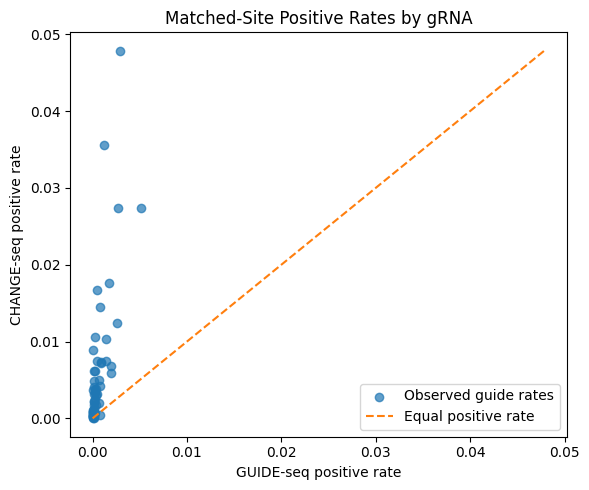

In [13]:
# Plotting the positive-label rate for each shared gRNA in both assays.
# Each point represents one guide and uses only candidate sites present in both datasets.
plt.figure(figsize=(6, 5))

plt.scatter(
    per_guide_matched['guide_rate'],
    per_guide_matched['change_rate'],
    color='C0',
    alpha=0.7,
    label='Observed guide rates'
)

# The diagonal represents equal positive rates in GUIDE-seq and CHANGE-seq.
# Points above this line have a higher positive rate in CHANGE-seq.
limit = max(
    per_guide_matched['guide_rate'].max(),
    per_guide_matched['change_rate'].max()
)

plt.plot(
    [0, limit],
    [0, limit],
    linestyle='--',
    color='C1',
    label='Equal positive rate'
)

plt.xlabel('GUIDE-seq positive rate')
plt.ylabel('CHANGE-seq positive rate')
plt.title('Matched-Site Positive Rates by gRNA')
plt.legend()

plt.tight_layout()

plt.savefig(
    'results/positive_rates.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Results

The guide-level comparison shows that the higher CHANGE-seq positive rate is widespread across the shared gRNAs rather than being driven solely by a small number of extreme guides. Most points lie above the equality line, indicating a higher positive-label rate in CHANGE-seq for the same matched candidate sites.

Several guides exhibit particularly large assay differences, demonstrating that the magnitude of the shift varies substantially between gRNAs. Nevertheless, the predominantly upward direction is consistent with the numerical finding that 55 of 58 shared guides have a higher positive rate in CHANGE-seq.

### Read-Count Robustness

CHANGE-seq active sites are defined using a read-count threshold greater than 100. To determine whether GUIDE-negative / CHANGE-positive disagreements are restricted to weak CHANGE-seq signals close to this threshold, progressively stricter CHANGE-seq read-count thresholds are applied to the discordant matched sites.

In [14]:
# Selects sites that are inactive in GUIDE-seq but active in CHANGE-seq.
# These are the dominant direction of cross-assay label disagreement.
change_only_positive = matched_sites[
    (matched_sites['label_guide'] == 0)
    & (matched_sites['label_change'] == 1)
].copy()

# CHANGE-seq positives should satisfy the > 100 read-count definition used when constructing the final labels
assert (change_only_positive['reads_change'] > 100).all()

# Tests different thresholds to see whether the disagreement persists when only stronger CHANGE-seq signals are retained
thresholds = [100, 250, 500, 1000, 5000, 10000]

rows = []
for threshold in thresholds:
    remaining = (
        change_only_positive['reads_change'] > threshold
    ).sum()
    rows.append({
        'CHANGE read threshold': f'> {threshold:,}',
        'discordant sites remaining': remaining,
        'percent of original discordance': (
            100 * remaining / len(change_only_positive)
        )
    })
threshold_results = pd.DataFrame(rows)

# Formats the proportion for easier interpretation.
threshold_results.style.format({
    'percent of original discordance': '{:.1f}%'
})

,CHANGE read threshold,discordant sites remaining,percent of original discordance
0,> 100,9730,100.0%
1,> 250,4938,50.8%
2,> 500,2674,27.5%
3,"> 1,000",1265,13.0%
4,"> 5,000",42,0.4%
5,"> 10,000",6,0.1%


### Results

The GUIDE-negative / CHANGE-positive disagreements were concentrated toward lower CHANGE-seq read counts, but were not restricted to sites immediately above the activity threshold. Approximately 50.8% of discordant sites remained when the threshold was increased from greater than 100 to greater than 250 reads, while 27.5% remained above 500 reads and 13.0% remained above 1,000 reads.

Only a small fraction of disagreements persisted at very high read counts. This indicates that weaker CHANGE-seq signals account for much of the cross-assay disagreement, while a substantial number of discordant sites remain even under considerably stricter activity thresholds.

## Input Distribution Shift

Differences in gRNA support already demonstrate that the model input distribution is not identical between GUIDE-seq and CHANGE-seq. CHANGE-seq contains additional gRNAs that are absent from GUIDE-seq, producing a direct shift in sequence support.

As an additional sequence-level comparison, the number of mismatches between each gRNA protospacer and candidate off-target protospacer is examined. Mismatch count does not capture the full sequence distribution, but provides an interpretable summary of whether candidate-site composition also differs between assays.

Protospacer mismatch distribution:
GUIDE mean mismatches: 5.356
CHANGE mean mismatches: 5.318
GUIDE median: 5.0
CHANGE median: 5.0
Total variation distance: 0.0261


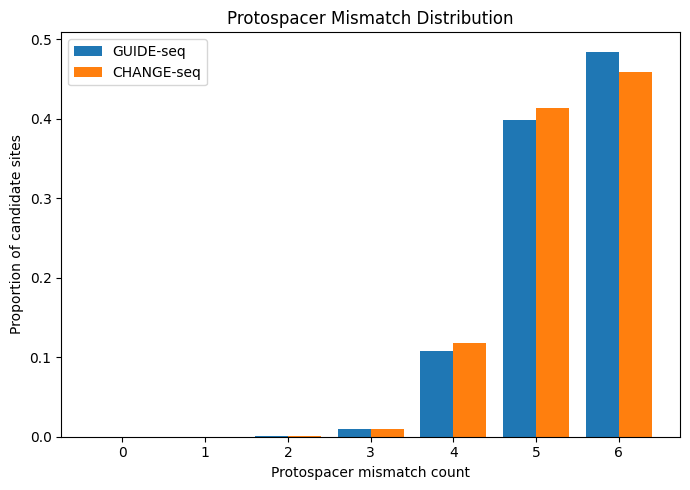

In [15]:
# Counts nucleotide mismatches across the 20 nt protospacer.
def protospacer_mismatch_counts(df):
    guides = np.asarray(
        df[GRNA_COL].str[:20],
        dtype='S20'
    )
    off_targets = np.asarray(
        df['offtarget_sequence'].str[:20],
        dtype='S20'
    )

    # Fixed-width byte strings can be viewed as individual nucleotides
    guide_chars = guides.view('S1').reshape(-1, 20)
    off_target_chars = off_targets.view('S1').reshape(-1, 20)

    return (guide_chars != off_target_chars).sum(axis=1)


guide_mismatches = protospacer_mismatch_counts(guide_full)
change_mismatches = protospacer_mismatch_counts(change_full)

# Converts mismatch counts into probability distributions so that datasets of different sizes can be compared directly
max_mismatches = int(
    max(guide_mismatches.max(), change_mismatches.max())
)

mismatch_values = np.arange(max_mismatches + 1)

guide_mismatch_dist = (
    np.bincount(guide_mismatches, minlength=max_mismatches + 1)
    / len(guide_mismatches)
)

change_mismatch_dist = (
    np.bincount(change_mismatches, minlength=max_mismatches + 1)
    / len(change_mismatches)
)

# Total variation distance is 0 for identical distributions and 1 for distributions with no overlap.
tv_distance = 0.5 * np.abs(
    guide_mismatch_dist - change_mismatch_dist
).sum()

print('Protospacer mismatch distribution:')
print(f'GUIDE mean mismatches: {guide_mismatches.mean():.3f}')
print(f'CHANGE mean mismatches: {change_mismatches.mean():.3f}')
print(f'GUIDE median: {np.median(guide_mismatches):.1f}')
print(f'CHANGE median: {np.median(change_mismatches):.1f}')
print(f'Total variation distance: {tv_distance:.4f}')

# Plotting the normalised mismatch distributions
width = 0.4

plt.figure(figsize=(7, 5))

plt.bar(
    mismatch_values - width / 2,
    guide_mismatch_dist,
    width=width,
    color='C0',
    label='GUIDE-seq'
)

plt.bar(
    mismatch_values + width / 2,
    change_mismatch_dist,
    width=width,
    color='C1',
    label='CHANGE-seq'
)

plt.xlabel('Protospacer mismatch count')
plt.ylabel('Proportion of candidate sites')
plt.title('Protospacer Mismatch Distribution')
plt.xticks(mismatch_values)
plt.legend()

plt.tight_layout()

plt.savefig(
    'results/mismatch_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Results

The protospacer mismatch distributions were highly similar between GUIDE-seq and CHANGE-seq. GUIDE-seq candidate sites contained a mean of 5.356 protospacer mismatches compared with 5.318 in CHANGE-seq, while both datasets had a median of five mismatches.

The total variation distance between the two mismatch-count distributions was 0.0261, indicating only a small difference in this sequence-level summary. Therefore, although the datasets differ in gRNA support and composition, there is little evidence that protospacer mismatch count itself undergoes substantial distribution shift.

## Characterisation of the Distribution Shift

- P(X) changed - Input drift: GUIDE-seq and CHANGE-seq have different gRNA support, although mismatch-count distributions are very similar.
- P(Y) changed - Label prevalence shift: positive prevalence increased from 0.000989 → 0.023481 in CHANGE-seq.
- P(Y∣X) changed - Cross-assay conditional relationship shift: even for the same gRNA and genomic site, CHANGE-seq produced substantially more positive labels (9,730 GUIDE−/CHANGE+ vs 106 GUIDE+/CHANGE−).
- Not covariate drift: covariate drift would require P(Y∣X) to remain stable, which the matched-site analysis contradicts.

Overall characterisation:

$P_{\text{GUIDE}}(X) \ne P_{\text{CHANGE}}(X)$

$P_{\text{GUIDE}}(Y) \ne P_{\text{CHANGE}}(Y)$

$P_{\text{GUIDE}}(Y \mid X) \ne P_{\text{CHANGE}}(Y \mid X)$

Best described as input drift + an assay-dependent shift in P(Y∣X), likely driven partly by differences in assay sensitivity rather than a change in the underlying biology.